In [1]:
# external
import numpy as np
from scipy.stats import norm
from scipy.interpolate import InterpolatedUnivariateSpline as spline
from scipy.optimize import curve_fit
from matplotlib.pyplot import *
cr = rcParams['axes.prop_cycle'].by_key()['color']
# from cmblensplus/utils/
import constant as c
import binning as bn
import plottools as pl
# local
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb

In [50]:
def plot_posterior(Pr,r0,mass,labs,xmax,figname,fsize=[8,5],old=False):
    pl.plot_1dstyle(fsize=fsize,usetex=True,xmin=0,xmax=xmax,ymin=0,ymax=1,
                    xlab=r'$r\times 10^3$',ylab=r'$P(r)/P_{\rm max}$',xlabsize=22,ylabsize=22,
                    xticks_labsize=16,yticks_labsize=16,legend_size=18)
    rcParams["font.family"] = "Arial"
    for i, (lab, m) in enumerate(zip(labs,mass)):
        color, ls = cr[i-1], '-'
        if m=='nodelens': color, ls = 'k', '--'
        plot(rs*1e3,Pr[r0,m]/np.max(Pr[r0,m]),label=lab,color=color,ls=ls)
    if old:
        legend()
    else:
        legend(loc=(-0.2, 1.03),ncol=3)
    savefig(figname, bbox_inches = 'tight', pad_inches = 0.1)

In [3]:
def gauss_fit(x,obsr,sig2):
    return np.exp(-(x-obsr)**2/(sig2*2.))

In [4]:
import importlib
importlib.reload(tools_delens)

<module 'tools_delens' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/tools_delens.py'>

In [34]:
simN = 500
lbmin, lbmax = 2, 190
bN = 15
area = 'lbfull'
sigma = 0.6827

In [35]:
pobj = local.analysis()
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename(method='cinv')

In [36]:
mask = tools_cmb.prepare_masks()
Fsky = {m: np.average(mask[m]) for m in tools_cmb.masks}
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')
L = np.linspace(0,lbmax,lbmax+1)
fsky = Fsky[area]
print(fsky)

0.4831339


In [37]:
rmax, dr = 2e-2, 2e-4
rs = np.arange(0.,rmax,dr)

In [38]:
Pr = {}
for obsr in [0.,1e-4,1e-3,2e-3,3e-3,4e-3,5e-3,1e-2]:
    print(obsr)
    for wmass in dobj.ctypes:
        print(wmass)
        Ob, Db, Rb = tools_delens.load_clbbs(dobj.cl[area][wmass],mb,simN,fsky)
        if wmass == 'klb':
            pr = np.array( [ norm.pdf([obsr],loc=r,scale=np.std(tools_delens.simple_r(Ob,Rb,r))) for r in rs ] )
            Pr[obsr,'nodelens'] = pr/(np.sum(pr)*dr)
        pr = np.array( [ norm.pdf([obsr],loc=r,scale=np.std(tools_delens.simple_r(Db,Rb,r))) for r in rs ] )
        Pr[obsr,wmass] = pr/(np.sum(pr)*dr)

0.0
klb
cib
gal
ext
all
0.0001
klb
cib
gal
ext
all
0.001
klb
cib
gal
ext
all
0.002
klb
cib
gal
ext
all
0.003
klb
cib
gal
ext
all
0.004
klb
cib
gal
ext
all
0.005
klb
cib
gal
ext
all
0.01
klb
cib
gal
ext
all


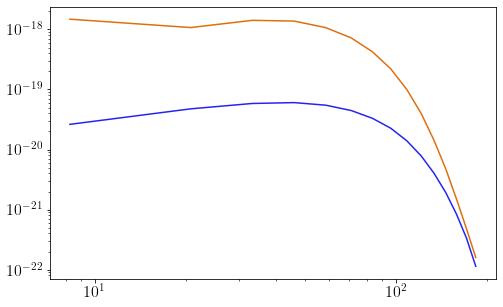

In [39]:
loglog(mb.bc,np.mean(Ob,axis=0))
loglog(mb.bc,np.mean(Rb,axis=0))

In [40]:
mass = np.concatenate((['nodelens'],dobj.ctypes))
labs  = [r'No-delensing',
         r'{\it LiteBIRD} internal',
         r'$+$ CIB',
         r'$+\,\delta_{\rm g}$',
         r'$+$ CIB $+\,\delta_{\rm g}$',
         r'$+$ CIB $+\,\delta_{\rm g}\,+$ CMB-S4'
        ]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


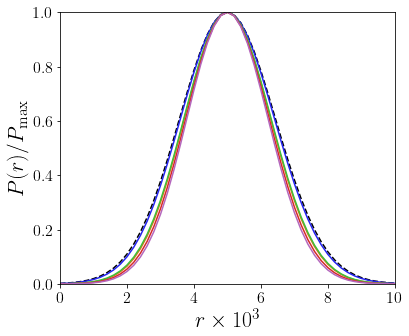

In [53]:
plot_posterior(Pr,5e-3,mass,['','','','','',''],10,'fig_Pr_r5_old.pdf',fsize=[6,5],old=True)

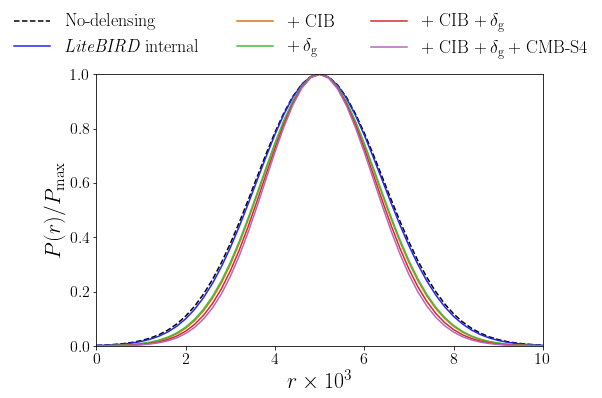

In [54]:
plot_posterior(Pr,5e-3,mass,labs,10,'fig_Pr_r5.pdf')

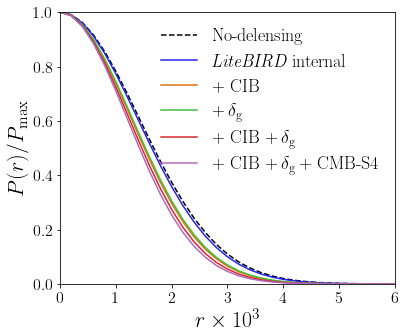

In [51]:
plot_posterior(Pr,0.,mass,labs,6,'fig_Pr_r0.pdf',fsize=[6,5],old=True)

0.0012749999999999999
0.0012749999999999999 1.0
0.001245
0.001245 0.9764705882352942
0.0011309999999999998
0.0011309999999999998 0.8870588235294117
0.001147
0.001147 0.899607843137255
0.001091
0.001091 0.855686274509804
0.001055
0.001055 0.8274509803921569


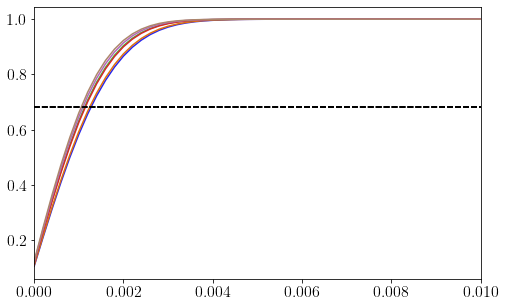

In [43]:
# sigma(r=0) from CDF
r_fine = np.arange(0.,5e-3,1e-6)
for i, wmass in enumerate(mass):
    xlim(0,1e-2)
    cdf = np.cumsum(Pr[0.,wmass]*dr)
    plot(rs,cdf)
    axhline(sigma,color='k',ls='--')
    cdf_sp = spline(rs,cdf)(r_fine)
    idx = np.abs(cdf_sp-sigma).argmin()
    print(r_fine[idx])
    sigr = r_fine[idx]
    if i==0: sig0 = sigr
    print(sigr,sigr/sig0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0014235608625333023 1.0
0.0013942498627370194 0.9794100831459202
0.0012805795852545068 0.8995608259246797
0.0012946134432417534 0.9094191034009743
0.001239124496996766 0.8704401263123223
0.0012036134522741557 0.8454949022216455


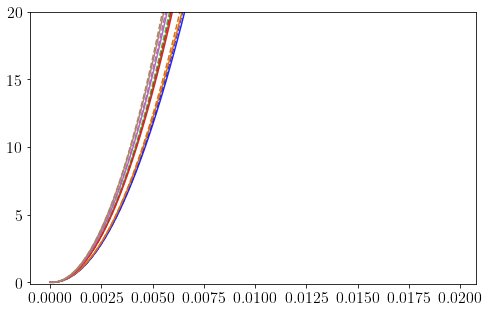

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0014271878648109777 1.0
0.00139746752956984 0.9791755970086853
0.0012839260076052605 0.8996194819630902
0.0012990358026337518 0.9102065920423176
0.0012432591319505013 0.8711250723219703
0.001207828968849614 0.8462999151198526


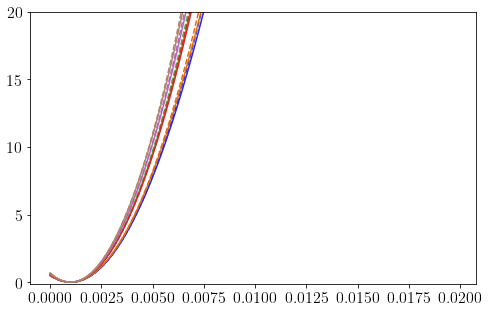

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0014281413577606897 1.0
0.0013984107561328465 0.9791823117044517
0.0012848963994979779 0.8996983334427634
0.0013000553669404117 0.9103128061348804
0.0012442067764161912 0.8712070199879192
0.0012087834454822084 0.8464032211612216


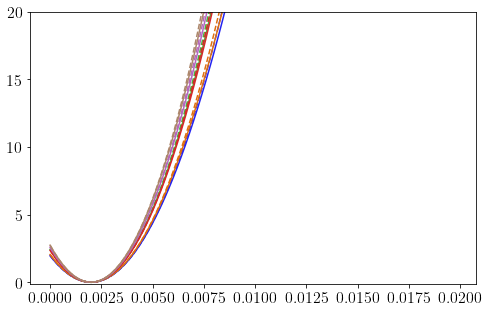

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0014303380956326708 1.0
0.0014009220600755678 0.979434208144969
0.0012872683737460604 0.8999748924233697
0.0013017577097107988 0.9101049001529963
0.0012460184398874895 0.8711356033178627
0.0012105953101074708 0.8463700392262832


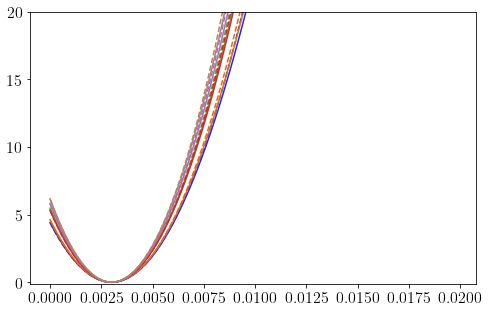

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0014337875250508233 1.0
0.0014048773071919287 0.9798364699414791
0.0012909454849877571 0.9003743319234119
0.0013045125432748074 0.9098367230029892
0.00124891088026566 0.8710571534798296
0.0012134909319692756 0.8463533897229725


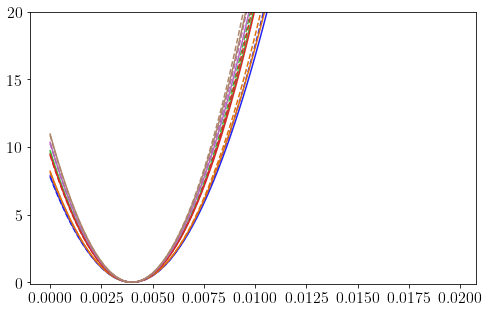

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0014384147466719698 1.0
0.0014100158067705646 0.9802567792306696
0.0012955738567910157 0.9006956163294056
0.0013083262672235515 0.9095612167843793
0.001252742219223187 0.8709186429864061
0.0012173129901019146 0.8462878963931553


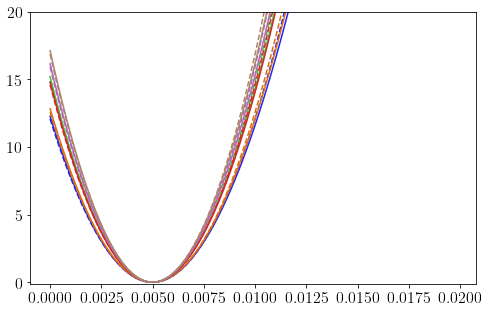

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0014704094031742102 1.0
0.0014438122745495385 0.9819117528987126
0.0013258050420133292 0.9016570753364881
0.0013363144470233447 0.9088043398924196
0.0012798360230224638 0.8703943406915443
0.0012443431071627444 0.8462562225707679


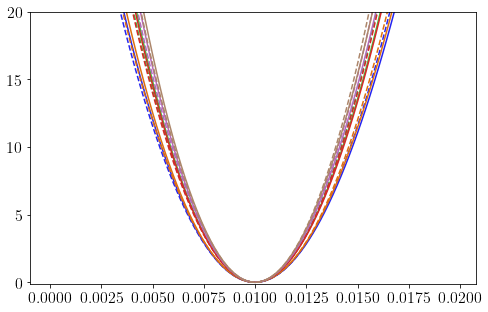

<Figure size 576x360 with 0 Axes>

In [44]:
for r0 in [1e-4,1e-3,2e-3,3e-3,4e-3,5e-3,1e-2]:
    #xlim(0,0.01)
    ylim(-0.1,20)
    for i, m in enumerate(mass):
        x2 = -2*np.log(Pr[r0,m]/np.max(Pr[r0,m]))
        plot(rs,x2,color=cr[i])
        #idx0 = np.abs(x2-0.).argmin()
        #idxp = np.abs(x2[idx0:]-1.).argmin()
        #idxm = np.abs(x2[:idx0]-1.).argmin()
        #print(rs[idx0+idxp],rs[idxm])
        popt, pcov = curve_fit(gauss_fit, rs, Pr[r0,m][:,0]/np.max(Pr[r0,m]), np.array([r0,r0**2]) )
        sigr = np.sqrt(popt[1])
        if i==0: sig0 = sigr
        print(sigr,sigr/sig0)
        pdf = norm.pdf(rs,loc=r0,scale=np.sqrt(popt[1]))
        plot(rs,-2*np.log(pdf/pdf.max()),color=cr[i],ls='--')
    legend()
    show()
    clf()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0015273136979861036
0.0015030656152769117
0.0013671584577951805
0.0013945273849397262
0.001325893709811472
0.0012826387260341584


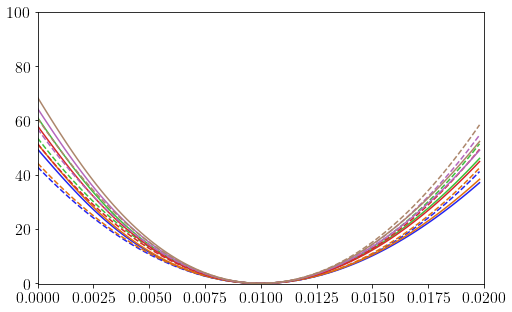

In [15]:
xlim(0,0.02)
ylim(-0.1,100)
r0 = 1e-2
for i, m in enumerate(mass):
    x2 = -2*np.log(Pr[r0,m]/np.max(Pr[r0,m]))
    idx0 = np.abs(x2-0.).argmin()
    idxp = np.abs(x2[idx0:]-1.).argmin()
    idxm = np.abs(x2[:idx0]-1.).argmin()
    #print(rs[idx0+idxp],rs[idxm])
    plot(rs,x2,color=cr[i])
    popt, pcov = curve_fit(gauss_fit, rs, Pr[r0,m][:,0]/np.max(Pr[r0,m]), np.array([r0,r0**2]) )
    #print(popt)
    print(np.sqrt(popt[1]))
    pdf = norm.pdf(rs,loc=r0,scale=popt[1]**0.5)
    plot(rs,-2*np.log(pdf/pdf.max()),color=cr[i],ls='--')
legend()